## Installing the required dependencies

In [ ]:
import pandas as pd
import gradio as gr

In [ ]:
merged_df = pd.read_csv('merged_df.csv')
merged_df.describe()

,catalog,mean_motion,eccentricity,orb incli,drag,semi_major_axis_km,h_p_km,delta_a,delta_t,decay_rate,mean_f107_adj,Ap
count,90830.000000,90830.000000,90830.000000,90830.000000,90830.000000,90830.000000,90830.000000,90694.000000,90694.000000,90694.000000,90817.000000,90817.000000
mean,51181.196323,15.247049,0.001061,96.693469,56.198080,6870.285864,484.795234,-0.089780,1.030752,-0.087273,151.552900,11.942143
std,8495.331150,0.169405,0.002013,4.823598,51.132248,51.495471,43.881135,0.387805,0.206817,0.321075,49.029553,14.371649
min,39132.000000,14.610985,0.000001,64.861850,-1101.377500,6590.859226,203.042342,-30.883927,1.000000,-15.441963,-1.000000,0.000000
25%,42988.000000,15.191617,0.000362,97.328800,26.187000,6832.500675,451.292223,-0.124121,1.000000,-0.121859,124.000000,5.000000
50%,55028.000000,15.266409,0.000678,97.422900,48.829250,6863.999683,481.043451,-0.073471,1.000000,-0.072096,154.600000,8.125000
75%,58318.000000,15.372101,0.001075,97.456200,75.277500,6886.509889,503.073384,-0.032334,1.000000,-0.032047,176.300000,13.875000
max,62685.000000,16.225187,0.014740,98.464150,5563.515800,7067.766396,621.750928,15.075907,6.000000,10.675062,412.900000,270.750000


## same regression- just additional plots

In [ ]:

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from scipy.stats import uniform, randint
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# Create folder to save plots
os.makedirs("plots", exist_ok=True)

results = {}

# Define base features
base_features = ["drag", "h_p_km", "semi_major_axis_km", "orb incli"]

# Param distributions for RandomizedSearch (note randint/uniform ranges)
param_distributions = {
    "model__n_estimators": randint(200, 1000),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.1),
    "model__subsample": uniform(0.6, 0.4),          # 0.6–1.0
    "model__colsample_bytree": uniform(0.6, 0.4),   # 0.6–1.0
    "model__reg_lambda": uniform(1, 10)
}

# Helper: remove outliers by IQR
def remove_outliers(df, col, factor=3.0):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return df[(df[col] >= lower) & (df[col] <= upper)]

for (alt_group, incl_group), group_df in merged_df.groupby(["altitude_group", "incli_group"]):
    print(f"\nChecking group: ({alt_group}, {incl_group}) with {len(group_df)} rows")

    df = group_df.copy()

    # Add solar features only for low-alt SSO
    if (alt_group == "Planet_low") and (incl_group == "Sun-synchronous"):
        features = base_features + ["mean_f107_adj", "Ap"]
    else:
        features = base_features

    features = [f for f in features if f in df.columns]
    df = df.dropna(subset=features + ["decay_rate"])

    if df.empty:
        continue

    df = remove_outliers(df, "decay_rate", factor=3.0)
    print(f" -> After outlier removal: {len(df)} rows remain")

    # Cluster-based subgrouping
    if alt_group == "Planet_mid":
        cluster_features = [f for f in base_features if f in df.columns]
        X_cluster = (df[cluster_features] - df[cluster_features].mean()) / df[cluster_features].std()
        kmeans = KMeans(n_clusters=3, random_state=42)
        df["cluster"] = kmeans.fit_predict(X_cluster)

        # ---- Save cluster separation plot ----
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x=X_cluster.iloc[:, 0], y=X_cluster.iloc[:, 1],
                        hue=df["cluster"], palette="tab10", s=50)
        plt.title(f"Cluster separation: {alt_group}, {incl_group}")
        plt.xlabel(cluster_features[0])
        plt.ylabel(cluster_features[1])
        plt.legend(title="Cluster")
        plt.tight_layout()
        plt.savefig(f"plots/{alt_group}_{incl_group}_cluster_separation.png", dpi=200)
        plt.close()
        subgroup_key = "cluster"
    else:
        df["cluster"] = 0
        subgroup_key = "cluster"

    for subgroup, sub_df in df.groupby(subgroup_key):
        print(f"   Subgroup {subgroup} with {len(sub_df)} rows")

        if len(sub_df) < 50:
            print("   -> Skipping (too few rows)")
            continue

        X = sub_df[features]
        y = sub_df["decay_rate"]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        numeric_features = X.columns.tolist()
        preprocessor = ColumnTransformer(
            transformers=[("num", RobustScaler(), numeric_features)],
            remainder="passthrough"
        )

        xgb = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)

        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", xgb)
        ])

        rand_search = RandomizedSearchCV(
            pipe, param_distributions, n_iter=30, cv=3,
            scoring="r2", random_state=42, n_jobs=-1, verbose=0
        )
        rand_search.fit(X_train, y_train)
        best_model = rand_search.best_estimator_

        y_pred = best_model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results[(alt_group, incl_group, subgroup)] = {
            "RMSE": rmse, "R2": r2, "best_params": rand_search.best_params_
        }

        print(f"   -> RMSE={rmse:.5f}, R²={r2:.5f}")

        # ---------- Save performance plots ----------
        # 1. Predicted vs Actual
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
        plt.xlabel("Actual decay_rate")
        plt.ylabel("Predicted decay_rate")
        plt.title(f"Perf: {alt_group}, {incl_group}, cluster {subgroup}\nR²={r2:.3f}, RMSE={rmse:.3f}")
        plt.tight_layout()
        plt.savefig(f"plots/{alt_group}_{incl_group}_cluster{subgroup}_performance.png", dpi=200)
        plt.close()

        # 2. Residual plot
        residuals = y_test - y_pred
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
        plt.axhline(0, color="r", linestyle="--")
        plt.xlabel("Predicted decay_rate")
        plt.ylabel("Residuals")
        plt.title(f"Residuals: {alt_group}, {incl_group}, cluster {subgroup}")
        plt.tight_layout()
        plt.savefig(f"plots/{alt_group}_{incl_group}_cluster{subgroup}_residuals.png", dpi=200)
        plt.close()

        # 3. Feature importance
        fitted_xgb = best_model.named_steps["model"]
        importances = fitted_xgb.feature_importances_
        fi = pd.Series(importances, index=numeric_features).sort_values(ascending=False)

        plt.figure(figsize=(6, 4))
        fi.plot(kind="bar")
        plt.title(f"Feature importances: {alt_group}, {incl_group}, cluster {subgroup}")
        plt.ylabel("Importance")
        plt.tight_layout()
        plt.savefig(f"plots/{alt_group}_{incl_group}_cluster{subgroup}_feat_importance.png", dpi=200)
        plt.close()



Checking group: (Planet_low, Sun-synchronous) with 1723 rows
 -> After outlier removal: 1686 rows remain
   Subgroup 0 with 1686 rows
   -> RMSE=0.18368, R²=0.84637

Checking group: (Planet_mid, Polar) with 3291 rows
 -> After outlier removal: 3266 rows remain
   Subgroup 0 with 594 rows
   -> RMSE=0.03555, R²=0.72212
   Subgroup 1 with 1313 rows
   -> RMSE=0.04661, R²=0.57221
   Subgroup 2 with 1359 rows
   -> RMSE=0.00664, R²=0.90306

Checking group: (Planet_mid, Sun-synchronous) with 85816 rows
 -> After outlier removal: 83577 rows remain
   Subgroup 0 with 30923 rows
   -> RMSE=0.03255, R²=0.78668
   Subgroup 1 with 43301 rows
   -> RMSE=0.03060, R²=0.78315
   Subgroup 2 with 9353 rows
   -> RMSE=0.00688, R²=0.92365


## Risk classification: only satellites falling under test set

In [ ]:
from sklearn.metrics import mean_absolute_error

# Assume sub_df contains satellite_id column
satellite_results = []

# Predict using best model
y_pred = best_model.predict(X_test)

# Collect residuals per sample
residuals_df = pd.DataFrame({
    "satellite_id": sub_df.loc[y_test.index]["catalog"].values,
    "y_true": y_test.values,
    "y_pred": y_pred,
})
residuals_df["residual"] = residuals_df["y_true"] - residuals_df["y_pred"]
residuals_df["abs_residual"] = residuals_df["residual"].abs()

# ---- Aggregate per satellite ----
satellite_mae = (
    residuals_df.groupby("satellite_id")["abs_residual"]
    .mean()
    .reset_index(name="mae_per_satellite")
)

# ---- Risk classification ----
# Method 1: quantile-based thresholds (top 25% = high, bottom 25% = low)
low_thr = satellite_mae["mae_per_satellite"].quantile(0.33)
high_thr = satellite_mae["mae_per_satellite"].quantile(0.66)

def classify_risk(mae):
    if mae <= low_thr:
        return "Low"
    elif mae <= high_thr:
        return "Medium"
    else:
        return "High"

satellite_mae["risk_category"] = satellite_mae["mae_per_satellite"].apply(classify_risk)

# ---- Save results ----
satellite_mae.to_csv(f"plots/{alt_group}_{incl_group}_cluster{subgroup}_risk.csv", index=False)

print(satellite_mae.head())


   satellite_id  mae_per_satellite risk_category
0         39418           0.001652           Low
1         39429           0.004461          High
2         40031           0.005563          High
3         40072           0.001437           Low
4         43788           0.002855        Medium


## Risk classification: all satellites

In [ ]:
# Use entire merged_df
features_full = base_features.copy()
if "mean_f107_adj" in merged_df.columns and "Ap" in merged_df.columns:
    features_full += ["mean_f107_adj", "Ap"]

# Drop NA
df_full = merged_df.dropna(subset=features_full + ["decay_rate", "catalog"])

X_full = df_full[features_full]
y_full = df_full["decay_rate"]

# Use best trained model on the full data
y_pred_full = best_model.predict(X_full)

# Residuals per satellite entry
residuals_df = pd.DataFrame({
    "satellite_id": df_full["catalog"].values,
    "y_true": y_full.values,
    "y_pred": y_pred_full
})
residuals_df["abs_residual"] = (residuals_df["y_true"] - residuals_df["y_pred"]).abs()

# Aggregate per satellite
satellite_mae = residuals_df.groupby("satellite_id")["abs_residual"].mean().reset_index()
satellite_mae.rename(columns={"abs_residual": "mae_per_satellite"}, inplace=True)

# Risk classification
low_thr = satellite_mae["mae_per_satellite"].quantile(0.33)
high_thr = satellite_mae["mae_per_satellite"].quantile(0.66)

def classify_risk(mae):
    if mae <= low_thr:
        return "Low"
    elif mae <= high_thr:
        return "Medium"
    else:
        return "High"

satellite_mae["risk_category"] = satellite_mae["mae_per_satellite"].apply(classify_risk)

print(f"Total satellites classified: {satellite_mae.shape[0]}")
pd.set_option('display.max_rows', 200)
satellite_mae.head()
print(satellite_mae)
satellite_mae.to_csv("plots/all_satellites_risk.csv", index=False)
satellite_mae['risk_category'].value_counts()



Total satellites classified: 136
     satellite_id  mae_per_satellite risk_category
0           39132           0.031051           Low
1           39418           0.004397           Low
2           39429           0.004151           Low
3           40031           0.036230           Low
4           40072           0.001496           Low
5           41601           0.116381          High
6           41771           0.096151          High
7           41772           0.064300          High
8           41773           0.102003          High
9           41774           0.134597          High
10          42987           0.129377          High
11          42988           0.130228          High
12          42989           0.096458          High
13          42990           0.125625          High
14          42991           0.127026          High
15          42992           0.128736          High
16          43788           0.036913           Low
17          43797           0.101083          Hig

,count
risk_category,
High,46
Low,45
Medium,45


## cluster-wise performance

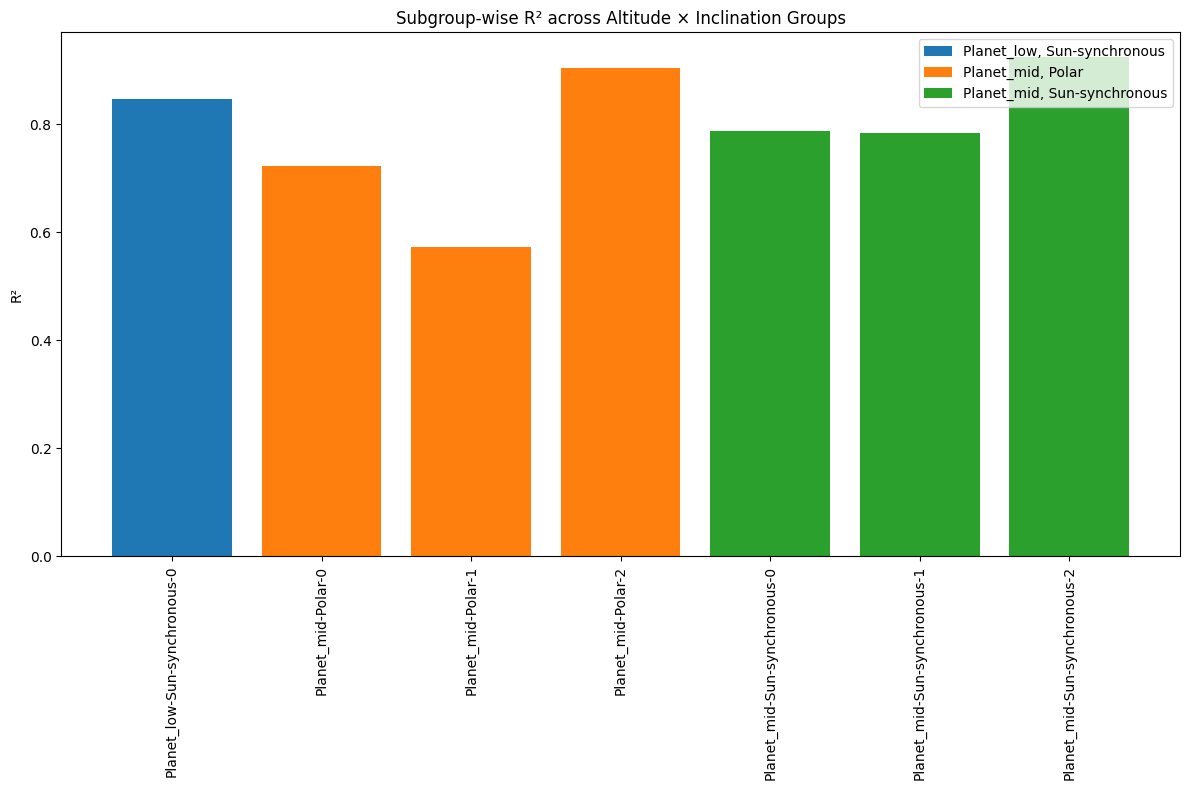

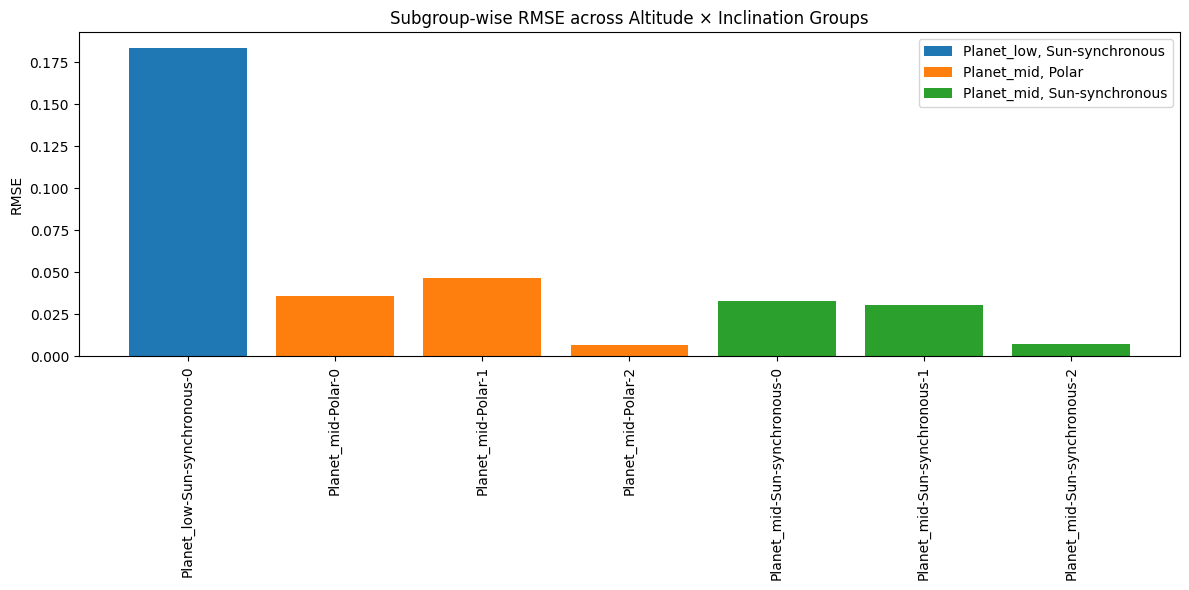

In [ ]:


# Convert results dict to DataFrame
summary_df = pd.DataFrame([
    {
        "alt_group": k[0],
        "incl_group": k[1],
        "subgroup": k[2],
        "RMSE": v["RMSE"],
        "R2": v["R2"]
    }
    for k, v in results.items()
])

# Plot R² per subgroup
plt.figure(figsize=(12,8))
for (alt, incl), grp in summary_df.groupby(["alt_group", "incl_group"]):
    plt.bar([f"{alt}-{incl}-{s}" for s in grp["subgroup"]], grp["R2"], label=f"{alt}, {incl}")
plt.xticks(rotation=90)
plt.ylabel("R²")
plt.title("Subgroup-wise R² across Altitude × Inclination Groups")
plt.legend()
plt.tight_layout()
plt.show()

# Plot RMSE per subgroup
plt.figure(figsize=(12,6))
for (alt, incl), grp in summary_df.groupby(["alt_group", "incl_group"]):
    plt.bar([f"{alt}-{incl}-{s}" for s in grp["subgroup"]], grp["RMSE"], label=f"{alt}, {incl}")
plt.xticks(rotation=90)
plt.ylabel("RMSE")
plt.title("Subgroup-wise RMSE across Altitude × Inclination Groups")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# Save in binary format (e.g., model.bin)
best_model.named_steps['model'].save_model('spacedout_xgboost_decayrate_model.bin')

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1028: UserWarning: [15:06:16] WARNING: /workspace/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)


## Create an Interface

In [ ]:
import gradio as gr
import requests
from datetime import datetime, timedelta

In [ ]:
features_full

['drag', 'h_p_km', 'semi_major_axis_km', 'orb incli', 'mean_f107_adj', 'Ap']

In [ ]:
merged_df.columns

Index(['catalog', 'date', 'mean_motion', 'eccentricity', 'orb incli', 'drag',
       'semi_major_axis_km', 'h_p_km', 'altitude_group', 'incli_group',
       'delta_a', 'delta_t', 'decay_rate', 'mean_f107_adj', 'Ap'],
      dtype='object')

In [ ]:
merged_df.catalog.unique()

array([39132, 39418, 39429, 40031, 40072, 41601, 41771, 41772, 41773,
       41774, 42987, 42988, 42989, 42990, 42991, 42992, 43788, 43797,
       43802, 43821, 55020, 55022, 55023, 55024, 55027, 55028, 55029,
       55032, 55042, 55043, 55063, 55065, 55068, 55074, 55077, 58270,
       58271, 58273, 58274, 58275, 58280, 58282, 58283, 58284, 58285,
       58286, 58296, 58303, 58304, 58306, 58307, 58308, 58309, 58311,
       58313, 58315, 58316, 58318, 58319, 58320, 58322, 58327, 58328,
       58329, 60480, 60481, 60482, 60483, 60484, 60486, 60487, 60488,
       60489, 60490, 60491, 60492, 60494, 60495, 60497, 60499, 60501,
       60502, 60503, 60505, 60507, 60509, 60511, 60512, 60513, 60514,
       60515, 60516, 60517, 60518, 60519, 60558, 60559, 60560, 60561,
       60563, 62613, 62621, 62622, 62624, 62625, 62629, 62631, 62633,
       62634, 62636, 62637, 62638, 62639, 62641, 62642, 62643, 62645,
       62646, 62647, 62650, 62651, 62652, 62659, 62660, 62661, 62663,
       62666, 62667,

In [ ]:
merged_df.date.iloc[0]

'2020-01-01'

In [ ]:
def get_ap_f107(d):
    geo_solar_url = f"https://kp.gfz.de/kpdata?startdate={d}&enddate={d}&format=kp1#kpdatadownload-143"
    resp = requests.get(geo_solar_url)
    if resp.status_code == 200:
        geo_solar_data = resp.text
        #print(geo_solar_data)
        geo_solar_data_lines = geo_solar_data.split("\n")
        aps = []
        l = geo_solar_data_lines[0]
        f107 = float(l[148:156])
        ap_start = 89
        for i in range(0,8):
            aps.append(float(l[ap_start:ap_start+4]))
            ap_start += 5
    return f107, sum(aps) / len(aps)

In [ ]:
def altitude_group_perigee(h_p):
    if h_p < 400:
        return "Planet_low"
    #elif h_p < 800:
    elif 400 <= h_p < 800:
        return "Planet_mid"
    else:
        return "Planet_high"

In [ ]:
def inclination_group(inc):
    """
    Categorize orbit type based on inclination in degrees.
    """
    if inc < 10:
        return "Equatorial"
    elif inc < 60:
        return "Mid-inclination"
    elif 97 <= inc <= 99:
        return "Sun-synchronous"
    elif inc < 120:
        return "Polar"
    else:
        return "Retrograde"

In [ ]:
MU = 398600.4418  # km^3 / s^2

def mean_motion_to_semi_major_axis(mean_motion):
    """
    Convert mean motion (rev/day) to semi-major axis (km).
    """
    n_rad_s = mean_motion * 2 * np.pi / 86400.0  # rev/day to rad/s
    a = (MU / (n_rad_s**2))**(1/3)
    return a

In [ ]:
def compute_altitude(semi_major_axis_km, eccentricity, earth_radius=6378.137):
    """
    Compute perigee and apogee altitudes from semi-major axis and eccentricity.

    Parameters
    ----------
    semi_major_axis : float
        Semi-major axis in km
    eccentricity : float
        Orbital eccentricity (0 <= e < 1)
    earth_radius : float, optional
        Mean radius of Earth in km (default 6378.137 km)

    Returns
    -------

        (perigee_altitude_km)
    """
    r_perigee = semi_major_axis_km * (1 - eccentricity)
    #r_apogee = semi_major_axis_km * (1 + eccentricity)

    h_perigee = r_perigee - earth_radius
    #h_apogee = r_apogee - earth_radius

    return h_perigee


In [ ]:
def decay_rate_predictor(cat,d):
  #get date
  row = merged_df[(merged_df.catalog==cat) & (merged_df.date==d)]
  X = row[features_full]
  pred_decay = best_model.predict(X)[0]

  abs_residual = (row["decay_rate"] - pred_decay).abs().iloc[0]
  risk = classify_risk(abs_residual)
  return f"{risk}: {pred_decay}"

In [ ]:

def parse_epoch(epoch_str):
    """Convert TLE epoch YYDDD.DDDDDDDD to datetime (UTC)."""
    year = int(epoch_str[0:2])
    year += 2000 if year < 57 else 1900  # TLE epoch rule
    doy = float(epoch_str[2:])  # day of year + fractional day
    day = int(doy)
    frac_day = doy - day
    dt = datetime(year, 1, 1) + timedelta(days=day - 1, seconds=frac_day * 86400)
    return dt


In [ ]:
def decay_rate_predictor_from_tle(tle):
    if len(tle.split("\n")) == 2:
        line1, line2 = tle.split("\n")[0].strip(), tle.split("\n")[1].strip()
        catalog = line1[2:7]
        epoch_str = line1[18:32].strip()
        mean_motion = line2[52:63].strip()
        #parse eccentricity (columns 27–33 on line 2, with implied decimal)
        eccentricity_str = line2[26:33].strip()
        eccentricity = float(f"0.{eccentricity_str}")

        # parse inclination (columns 9–16 on line 2)
        inclination = float(line2[8:16].strip())

        # parse B* drag term (line 1, cols 54–61)
        bstar_str = line1[53:61].strip()
        # format like "10270-3" → "0.10270e-3"
        if "-" in bstar_str or "+" in bstar_str:
            base, exp = bstar_str[:-2], bstar_str[-2:]
            bsr = float(f"{base}e{exp}")
        else:
            bsr = float(bstar_str)

        epoch_dt = parse_epoch(epoch_str)
        f107, Ap = get_ap_f107(epoch_dt.strftime("%Y-%m-%d"))
        sma = mean_motion_to_semi_major_axis(float(mean_motion))
        hpkm = compute_altitude(sma, eccentricity)
        X = pd.DataFrame([{'drag':bsr,'h_p_km':hpkm, 'semi_major_axis_km':sma,'orb incli':inclination,
                          'mean_f107_adj':f107,'Ap':Ap}])
        pred_decay = best_model.predict(X)[0]

        abs_residual = (row["decay_rate"] - pred_decay).abs().iloc[0]
        risk = classify_risk(abs_residual)
        return f"{risk}: {pred_decay}",altitude_group_perigee(hpkm),inclination_group(inclination)
    else:
        return "Invalid TLE format", "UNK","UNK"

In [ ]:
def update_dates(satellite):
    """
    Returns a new Gradio Dropdown component with date choices
    based on the selected satellite.
    """
    print(f"Grabbing dates for {satellite}")
    if satellite in merged_df.catalog.unique():
        new_choices = list(merged_df[merged_df.catalog==satellite].date.unique())
    else:
        new_choices = []
    return gr.Dropdown(choices=new_choices, interactive=True)

In [ ]:
def update_alt(sat,d):
    if sat == None:
      return ""
    if sat in merged_df.catalog.unique():
        row = merged_df[(merged_df.catalog==sat) & (merged_df.date==d)]
        alt_group = row['altitude_group'].iloc[0]
        return alt_group
    else:
        return "UNK"

In [ ]:
def update_inc(sat,d):
    if sat == None:
      return ""
    if sat in merged_df.catalog.unique():
        row = merged_df[(merged_df.catalog==sat) & (merged_df.date==d)]
        inc_group = row['incli_group'].iloc[0]
        return inc_group
    else:
        return "UNK"

In [ ]:
def clear_fields():
    return "", "", "","",""

In [ ]:
with gr.Blocks(theme=gr.themes.Default(primary_hue="gray", secondary_hue="red")) as demo:
    with gr.Row():
        gr.Markdown("\n\n # Decay Rate Predictor")
        img1 = gr.Image("logo2.png",height=200,width=200)
    with gr.Tabs():
        with gr.Tab("Our Catalog"):
            with gr.Row():
                with gr.Column(scale=1, min_width=300):
                    # First dropdown for countries
                    sat_dropdown = gr.Dropdown(
                                   label="Select a Satellite",
                                   choices=[""]+list(merged_df.catalog.unique()),
                                   interactive=True
                                  )
                    # Second dropdown for cities (initially empty)
                    date_dropdown = gr.Dropdown(
                                    label="Select a Date",
                                    choices=[],
                                    interactive=True
                                   )

                    sub_btn = gr.Button("Submit",variant="secondary")
                    clear_btn = gr.ClearButton(components=[sat_dropdown,date_dropdown,alt_txt,inc_txt,pred_decay_out])

                with gr.Column(scale=2, min_width=300):
                    alt_txt = gr.Textbox(label="Altitude Group:",interactive=True)
                    inc_txt = gr.Textbox(label="Inclination Group:",interactive=True)
                with gr.Column(scale=3, min_width=300):
                    pred_decay_out = gr.Textbox(label="Predicted Decay Rate")
            # Attach the change event listener
            # When `sat_dropdown` changes, run `update_dates` and update `date_dropdown`.
            sat_dropdown.change(
                                fn=update_dates,
                                inputs=[sat_dropdown],
                                outputs=[date_dropdown]
                               )


            # When `date_dropdown` changes, run `update_alt` and `update_inc` to update `alt_txt` and `inc_txt`
            date_dropdown.select(fn=update_alt,
                                inputs=[sat_dropdown,date_dropdown],
                                outputs=[alt_txt])
            date_dropdown.select(fn=update_inc,
                                inputs=[sat_dropdown,date_dropdown],
                                outputs=[inc_txt])
            sub_btn.click(
                fn=decay_rate_predictor,
                inputs=[sat_dropdown,date_dropdown],
                outputs=[pred_decay_out]
            )
            clear_btn.click(fn=clear_fields, outputs=[sat_dropdown,date_dropdown,alt_txt,inc_txt,pred_decay_out])
        with gr.Tab("Upload TLE"):
            with gr.Row():
                with gr.Column(scale=1, min_width=300):
                    input_tle = gr.Textbox(label="Your TLE")
                    cust_sub_btn = gr.Button("Submit",variant="secondary")
                    cust_clear_btn = gr.ClearButton(components=[input_tle,custom_alt_txt,custom_inc_txt,pred_decay_out])
                with gr.Column(scale=2, min_width=300):
                    custom_alt_txt = gr.Textbox(label="Altitude Group:")
                    custom_inc_txt = gr.Textbox(label="Inclination Group:")
                with gr.Column(scale=3, min_width=300):
                    cust_pred_decay_out = gr.Textbox(label="Predicted Decay Rate")
            cust_sub_btn.click(
                fn=decay_rate_predictor_from_tle,
                inputs=[input_tle],
                outputs=[cust_pred_decay_out,custom_alt_txt,custom_inc_txt]
            )
            cust_clear_btn.click(fn=clear_fields,outputs=[input_tle,custom_alt_txt,custom_inc_txt,cust_pred_decay_out])
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4217a9cc52fc98ec10.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
with gr.Blocks() as demo:
    gr.Markdown("# Decay Rate Predictor")

    with gr.Tabs():
        with gr.Tab("Our Catalog"):
            with gr.Row():
                # First dropdown for countries
                sat_dropdown = gr.Dropdown(
                                   label="Select a Satellite",
                                   choices=[""]+list(merged_df.catalog.unique()),
                                   interactive=True
                                  )

                # Second dropdown for cities (initially empty)
                date_dropdown = gr.Dropdown(
                                    label="Select a Date",
                                    choices=[],
                                    interactive=True
                                   )
            with gr.Row():
                with gr.Column(scale=1):
                    alt_txt = gr.Textbox(label="Altitude Group:",interactive=True)
                    inc_txt = gr.Textbox(label="Inclination Group:",interactive=True)
                with gr.Column(scale=2):
                    pred_decay_out = gr.Textbox(label="Predicted Decay Rate")
                    gr.Interface(fn=decay_rate_predictor, inputs=[sat_dropdown,date_dropdown], outputs=pred_decay_out)
            # Attach the change event listener
            # When `sat_dropdown` changes, run `update_dates` and update `date_dropdown`.
            sat_dropdown.change(
                                fn=update_dates,
                                inputs=[sat_dropdown],
                                outputs=[date_dropdown]
                               )

            # Attach the change event listener
            # When `date_dropdown` changes, run `update_alt` and `update_inc` to update `alt_txt` and `inc_txt`
            date_dropdown.change(fn=update_alt,
                                inputs=[sat_dropdown,date_dropdown],
                                outputs=[alt_txt])
            date_dropdown.change(fn=update_inc,
                                inputs=[sat_dropdown,date_dropdown],
                                outputs=[inc_txt])


        with gr.Tab("Upload TLE"):
            input_tle = gr.Textbox(label="Your TLE")
            #input_f107 = gr.Textbox(label="Corresponding F10.7")
            #input_ap = gr.Textbox(label="Corresponding Ap")
            pred_decay_out = gr.Textbox(label="Predicted Decay Rate")
            gr.Interface(fn=decay_rate_predictor_from_tle, inputs=[input_tle], outputs=pred_decay_out)
demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5455d19f19ed5f268e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7864 <> https://5455d19f19ed5f268e.gradio.live
